In [127]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("/Users/karlyn/Downloads/METABRIC_RNA_Mutation.csv")
print(df.shape)
df.head()

(1904, 693)


/var/folders/d0/kk1nw8tn2t502y3p5gfp5yxc0000gn/T/ipykernel_2130/592801649.py:5: DtypeWarning: Columns (678,688,690,692) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("/Users/karlyn/Downloads/METABRIC_RNA_Mutation.csv")


,patient_id,age_at_diagnosis,type_of_breast_surgery,cancer_type,cancer_type_detailed,cellularity,chemotherapy,pam50_+_claudin-low_subtype,cohort,er_status_measured_by_ihc,...,mtap_mut,ppp2cb_mut,smarcd1_mut,nras_mut,ndfip1_mut,hras_mut,prps2_mut,smarcb1_mut,stmn2_mut,siah1_mut
0,0,75.65,MASTECTOMY,Breast Cancer,Breast Invasive Ductal Carcinoma,NaN,0,claudin-low,1.0,Positve,...,0,0,0,0,0,0,0,0,0,0
1,2,43.19,BREAST CONSERVING,Breast Cancer,Breast Invasive Ductal Carcinoma,High,0,LumA,1.0,Positve,...,0,0,0,0,0,0,0,0,0,0
2,5,48.87,MASTECTOMY,Breast Cancer,Breast Invasive Ductal Carcinoma,High,1,LumB,1.0,Positve,...,0,0,0,0,0,0,0,0,0,0
3,6,47.68,MASTECTOMY,Breast Cancer,Breast Mixed Ductal and Lobular Carcinoma,Moderate,1,LumB,1.0,Positve,...,0,0,0,0,0,0,0,0,0,0
4,8,76.97,MASTECTOMY,Breast Cancer,Breast Mixed Ductal and Lobular Carcinoma,High,1,LumB,1.0,Positve,...,0,0,0,0,0,0,0,0,0,0


In [129]:
for col in df.columns:
    print(col)

patient_id
age_at_diagnosis
type_of_breast_surgery
cancer_type
cancer_type_detailed
cellularity
chemotherapy
pam50_+_claudin-low_subtype
cohort
er_status_measured_by_ihc
er_status
neoplasm_histologic_grade
her2_status_measured_by_snp6
her2_status
tumor_other_histologic_subtype
hormone_therapy
inferred_menopausal_state
integrative_cluster
primary_tumor_laterality
lymph_nodes_examined_positive
mutation_count
nottingham_prognostic_index
oncotree_code
overall_survival_months
overall_survival
pr_status
radio_therapy
3-gene_classifier_subtype
tumor_size
tumor_stage
death_from_cancer
brca1
brca2
palb2
pten
tp53
atm
cdh1
chek2
nbn
nf1
stk11
bard1
mlh1
msh2
msh6
pms2
epcam
rad51c
rad51d
rad50
rb1
rbl1
rbl2
ccna1
ccnb1
cdk1
ccne1
cdk2
cdc25a
ccnd1
cdk4
cdk6
ccnd2
cdkn2a
cdkn2b
myc
cdkn1a
cdkn1b
e2f1
e2f2
e2f3
e2f4
e2f5
e2f6
e2f7
e2f8
src
jak1
jak2
stat1
stat2
stat3
stat5a
stat5b
mdm2
tp53bp1
adam10
adam17
aph1a
aph1b
arrdc1
cir1
ctbp1
ctbp2
cul1
dll1
dll3
dll4
dtx1
dtx2
dtx3
dtx4
ep300
fbxw7
hda

In [143]:
# target column
target_col = "pam50_+_claudin-low_subtype"
#check subtypes
print("\nUnique subtype labels:")
print(df[target_col].dropna().unique())

#keep only 4 subtypes
valid_classes = ["LumA", "LumB", "Her2", "Basal"]
df = df.dropna(subset=[target_col]).copy()
df = df[df[target_col].isin(valid_classes)].copy()
print("\nSubtype counts after filtering to 4 classes:")
print(df[target_col].value_counts())

#clinical columns to remove
clinical_cols = [
    'patient_id', 'age_at_diagnosis', 'type_of_breast_surgery',
    'cancer_type', 'cancer_type_detailed', 'cellularity',
    'chemotherapy', 'cohort', 'er_status_measured_by_ihc',
    'er_status', 'neoplasm_histologic_grade',
    'her2_status_measured_by_snp6', 'her2_status',
    'tumor_other_histologic_subtype', 'hormone_therapy',
    'inferred_menopausal_state', 'integrative_cluster',
    'primary_tumor_laterality', 'lymph_nodes_examined_positive',
    'mutation_count', 'nottingham_prognostic_index',
    'oncotree_code', 'overall_survival_months',
    'overall_survival', 'pr_status', 'radio_therapy',
    '3-gene_classifier_subtype', 'tumor_size',
    'tumor_stage', 'death_from_cancer'
]
#mutation columns 
mutation_cols = [col for col in df.columns if col.endswith("_mut")]
print("\nNumber of clinical columns removed:", len(clinical_cols))
print("Number of mutation columns removed:", len(mutation_cols))

#keep only gene columns 
remove_cols = clinical_cols + mutation_cols + [target_col]
remove_cols = [col for col in remove_cols if col in df.columns]
gene_cols = [col for col in df.columns if col not in remove_cols]
print("Initial gene columns:", len(gene_cols))
print("First 20 gene columns:", gene_cols[:20])
#convert gene to numeric 
df[gene_cols] = df[gene_cols].apply(pd.to_numeric, errors="coerce")
#removal all missing gene columns 
all_missing_genes = [col for col in gene_cols if df[col].isnull().all()]
print("All-missing gene columns:", len(all_missing_genes))
print("First 20 all-missing genes:", all_missing_genes[:20])
gene_cols = [col for col in gene_cols if col not in all_missing_genes]
print("Remaining gene columns after removing all-missing:", len(gene_cols))

#creating x and y 
X = df[gene_cols]
y = df[target_col]
#fill missing values
imputer = SimpleImputer(strategy="median")
X = pd.DataFrame(imputer.fit_transform(X), columns=gene_cols)

#remove low variance genes
variances = X.var()
X = X.loc[:, variances > 0.01]
print("Genes after filtering:", X.shape[1])

# standardize data
scaler = StandardScaler()
X = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

# combine into clean dataset
clean_df = pd.concat([X, y.reset_index(drop=True)], axis=1)

print(clean_df.shape)


Unique subtype labels:
['LumA' 'LumB' 'Her2' 'Basal']

Subtype counts after filtering to 4 classes:
pam50_+_claudin-low_subtype
LumA     679
LumB     461
Her2     220
Basal    199
Name: count, dtype: int64

Number of clinical columns removed: 30
Number of mutation columns removed: 173
Initial gene columns: 489
First 20 gene columns: ['brca1', 'brca2', 'palb2', 'pten', 'tp53', 'atm', 'cdh1', 'chek2', 'nbn', 'nf1', 'stk11', 'bard1', 'mlh1', 'msh2', 'msh6', 'pms2', 'epcam', 'rad51c', 'rad51d', 'rad50']
All-missing gene columns: 0
First 20 all-missing genes: []
Remaining gene columns after removing all-missing: 489
Genes after filtering: 489
(1559, 490)


Training shape: (1247, 489)
Test shape: (312, 489)
             brca1        brca2        palb2         pten         tp53  \
count  1247.000000  1247.000000  1247.000000  1247.000000  1247.000000   
mean      0.009986    -0.016709     0.006595     0.008180     0.018283   
std       1.006871     1.015108     1.013019     1.030005     1.009395   
min      -2.528662    -2.759522    -4.424036    -5.798039    -2.433713   
25%      -0.677760    -0.716254    -0.677579    -0.544865    -0.665062   
50%      -0.128828    -0.079177     0.006529     0.130177     0.008101   
75%       0.568716     0.621024     0.666270     0.670300     0.667269   
max       4.419081     3.788280     4.472285     3.239485     4.216405   

               atm         cdh1        chek2          nbn          nf1  ...  \
count  1247.000000  1247.000000  1247.000000  1247.000000  1247.000000  ...   
mean      0.021400    -0.019218    -0.007132    -0.002334     0.005559  ...   
std       1.002816     1.001833     1.009494 

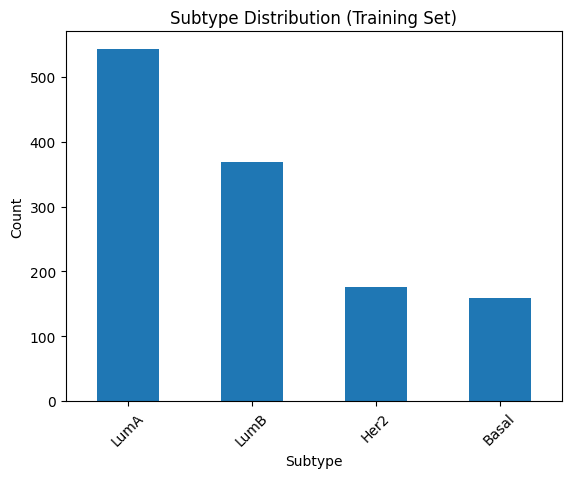

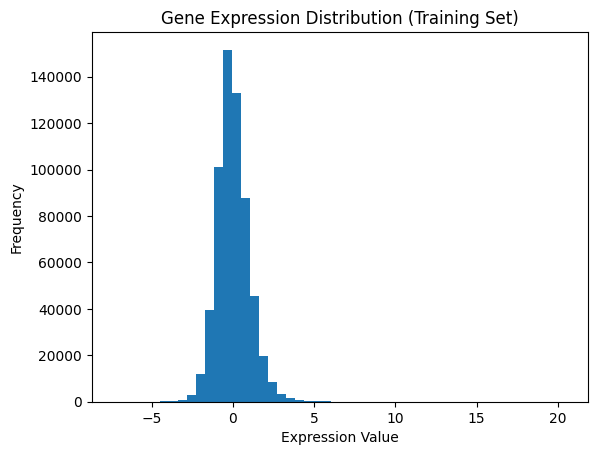

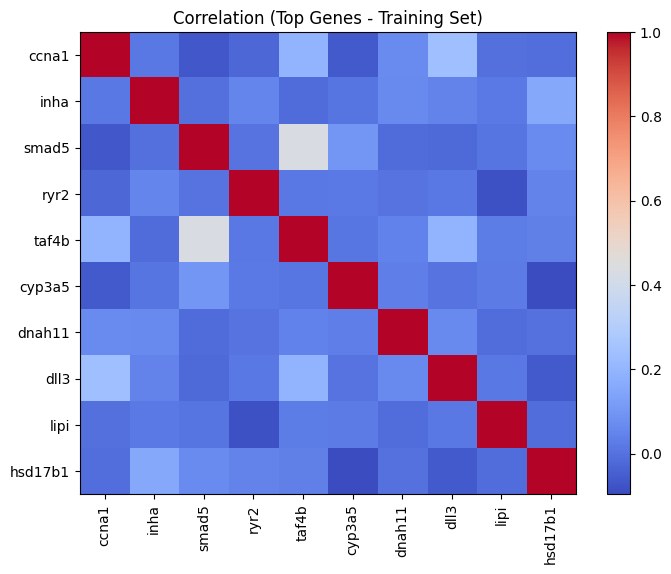

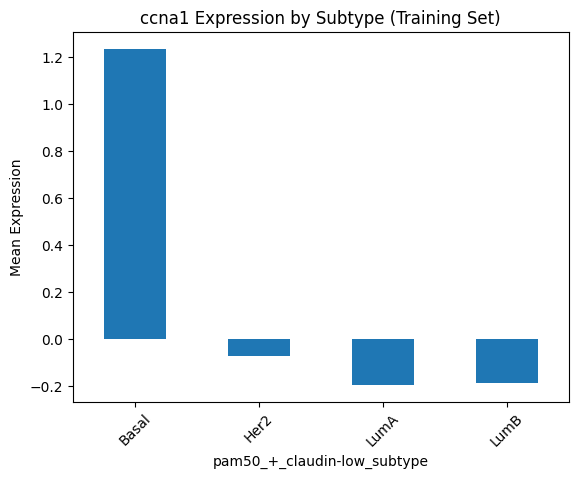

In [163]:
#data exploration with training set
from sklearn.model_selection import train_test_split

X = clean_df.drop(columns=[target_col])
y = clean_df[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
print("Training shape:", X_train.shape)
print("Test shape:", X_test.shape)
#descriptive statistics
print(X_train.describe())
#class distribution 
y_train.value_counts().plot(kind="bar")
plt.title("Subtype Distribution (Training Set)")
plt.xlabel("Subtype")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()
#gene exprssion
plt.hist(X_train.values.flatten(), bins=50)
plt.title("Gene Expression Distribution (Training Set)")
plt.xlabel("Expression Value")
plt.ylabel("Frequency")
plt.show()
#correlation top gens only
top_genes = X_train.var().sort_values(ascending=False).head(10).index
corr_matrix = X_train[top_genes].corr()
plt.figure(figsize=(8,6))
plt.imshow(corr_matrix, cmap='coolwarm', aspect='auto')
plt.colorbar()
plt.xticks(range(len(top_genes)), top_genes, rotation=90)
plt.yticks(range(len(top_genes)), top_genes)
plt.title("Correlation (Top Genes - Training Set)")
plt.show()
#gene expression by subtype
gene = top_genes[0]
train_df = X_train.copy()
train_df[target_col] = y_train
train_df.groupby(target_col)[gene].mean().plot(kind="bar")
plt.title(f"{gene} Expression by Subtype (Training Set)")
plt.ylabel("Mean Expression")
plt.xticks(rotation=45)
plt.show()

In [ ]:
#BASELINE MODELS

Logistic Regression Accuracy: 0.8076923076923077
              precision    recall  f1-score   support

       Basal       0.89      0.85      0.87        40
        Her2       0.71      0.80      0.75        44
        LumA       0.85      0.85      0.85       136
        LumB       0.76      0.73      0.74        92

    accuracy                           0.81       312
   macro avg       0.80      0.81      0.80       312
weighted avg       0.81      0.81      0.81       312

Random Forest Accuracy: 0.8525641025641025
              precision    recall  f1-score   support

       Basal       1.00      0.85      0.92        40
        Her2       0.84      0.73      0.78        44
        LumA       0.84      0.93      0.88       136
        LumB       0.82      0.80      0.81        92

    accuracy                           0.85       312
   macro avg       0.88      0.83      0.85       312
weighted avg       0.86      0.85      0.85       312



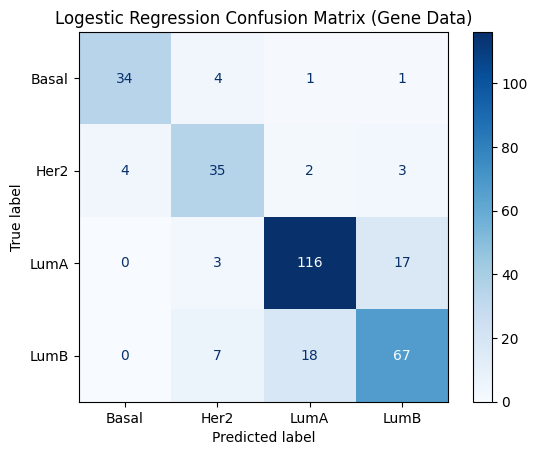

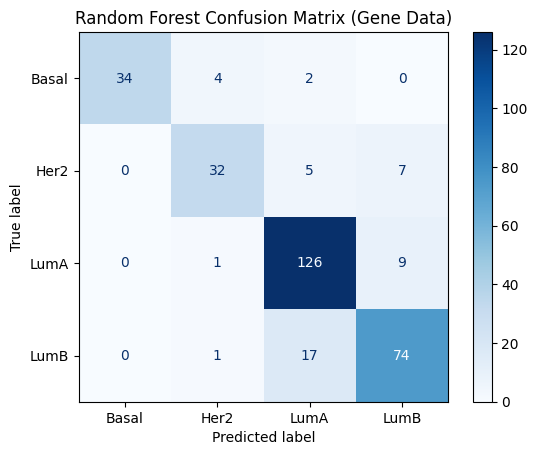

In [320]:
#imports
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay
# logistic regression baseline model
logestic_model = LogisticRegression(max_iter=1000)
logestic_model.fit(X_train,y_train)
y_pred_log = logestic_model.predict(X_test)

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_log))
print(classification_report(y_test,y_pred_log))

#random forest
rf_model = RandomForestClassifier(n_estimators=100)
rf_model.fit(X_train,y_train)
y_pred_rf = rf_model.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test,y_pred_rf))

#confusion matrices for LR and RF
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_estimator(logestic_model, X_test, y_test, cmap="Blues")
plt.title("Logestic Regression Confusion Matrix (Gene Data)")
plt.show()

ConfusionMatrixDisplay.from_estimator(rf_model,X_test,y_test, cmap="Blues")
plt.title("Random Forest Confusion Matrix (Gene Data)")
plt.show()

In [ ]:
#DEEP LEARNING 

In [207]:
#imports
import torch
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import LabelEncoder

#encode labels 
label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)
#convert to tensors
X_train_tensor = torch.tensor(X_train.values, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test.values, dtype=torch.float32)

y_train_tensor = torch.tensor(y_train_encoded, dtype=torch.long)
y_test_tensor = torch.tensor(y_test_encoded, dtype=torch.long)

#dataloaders
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, shuffle=True, batch_size=32)
test_loader = DataLoader(test_dataset, batch_size=32)

input_dim = X_train.shape[1]
num_clases = len(label_encoder.classes_)

#quick check 
print("Input dimension:", input_dim)
print("Classes:", label_encoder.classes_)

Input dimension: 489
Classes: ['Basal' 'Her2' 'LumA' 'LumB']


In [239]:
#imports 
import torch.nn as nn 
import pytorch_lightning as pl

#MLP model 
class MLPModel(pl.LightningModule):
    def __init__(self, input_dim, num_classes):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim,64),
            nn.ReLU(),
            nn.Linear(64,32),
            nn.ReLU(),
            nn.Linear(32, num_classes)
        )

        self.loss_fn = nn.CrossEntropyLoss() 
    def forward(self, x):
        return self.model(x)

    def training_step(self, batch, batch_idx):
        x, y = batch
        loss = self.loss_fn(self(x), y)
        return loss

    def configure_optimizers(self):
        return torch.optim.Adam(self.parameters(), lr=0.001)


In [241]:
#train model
# number of classes
num_classes = len(label_encoder.classes_)
model = MLPModel(input_dim=input_dim, num_classes=num_classes)
trainer = pl.Trainer(max_epochs=20,logger=False)
trainer.fit(model, train_loader)


Epoch 19/19 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 39/39 0:00:00 • 0:00:00 125.30it/s  

`Trainer.fit` stopped: `max_epochs=20` reached.


MLP Accuracy: 0.8461538461538461
              precision    recall  f1-score   support

       Basal       0.88      0.88      0.88        40
        Her2       0.78      0.80      0.79        44
        LumA       0.88      0.86      0.87       136
        LumB       0.82      0.84      0.83        92

    accuracy                           0.85       312
   macro avg       0.84      0.84      0.84       312
weighted avg       0.85      0.85      0.85       312



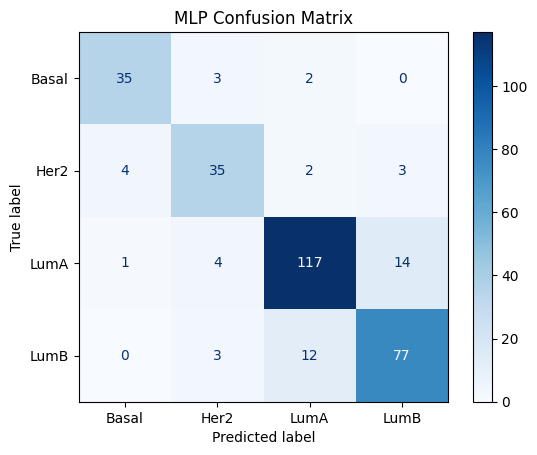

In [251]:
#evaluate model
from sklearn.metrics import accuracy_score, classification_report 

model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for x, y in test_loader:
        outputs = model(x)
        preds = torch.argmax(outputs, dim=1)
        all_preds.extend(preds.numpy())
        all_labels.extend(y.numpy())

print("MLP Accuracy:", accuracy_score(all_labels, all_preds))
print(classification_report(all_labels, all_preds, target_names=label_encoder.classes_))

#confusion matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_encoder.classes_)

disp.plot(cmap="Blues")
plt.title("MLP Confusion Matrix")
plt.show()

In [282]:
#autoencoder classifier 
class Autoencoder(pl.LightningModule):
    def __init__(self, input_dim):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 32)
        )
        self.decoder = nn.Sequential(
            nn.Linear(32, 64),
            nn.ReLU(),
            nn.Linear(64, input_dim)
        )
        self.loss_fn = nn.MSELoss()
    def forward(self, x):
        z = self.encoder(x)
        x_hat = self.decoder(z)
        return x_hat
    def training_step(self, batch, batch_idx):
        x, _ = batch
        x_hat = self(x)
        loss = self.loss_fn(x_hat, x)
        return loss
    def configure_optimizers(self):
        return torch.optim.Adam(self.parameters(), lr=0.001)


class AEClassifier(pl.LightningModule):
    def __init__(self, encoder, num_classes):
        super().__init__()
        self.encoder = encoder
        self.classifier = nn.Linear(32, num_classes)
        self.loss_fn = nn.CrossEntropyLoss()
    def forward(self, x):
        z = self.encoder(x)
        return self.classifier(z)
    def training_step(self, batch, batch_idx):
        x, y = batch
        loss = self.loss_fn(self(x), y)
        return loss
    def configure_optimizers(self):
        return torch.optim.Adam(self.parameters(), lr=0.001)

In [284]:
#train autoencoder
ae_model = Autoencoder(input_dim=input_dim)
trainer = pl.Trainer(max_epochs=20, logger=False)
trainer.fit(ae_model, train_loader)
#train classifer
ae_classifier= AEClassifier(ae_model.encoder, num_classes=num_classes)
trainer = pl.Trainer(max_epochs=20, logger=False)
trainer.fit(ae_classifier, train_loader)

Epoch 19/19 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 39/39 0:00:00 • 0:00:00 129.76it/s  

`Trainer.fit` stopped: `max_epochs=20` reached.


AE Classifier Accuracy: 0.8461538461538461
              precision    recall  f1-score   support

       Basal       0.88      0.88      0.88        40
        Her2       0.76      0.80      0.78        44
        LumA       0.88      0.87      0.87       136
        LumB       0.83      0.83      0.83        92

    accuracy                           0.85       312
   macro avg       0.84      0.84      0.84       312
weighted avg       0.85      0.85      0.85       312



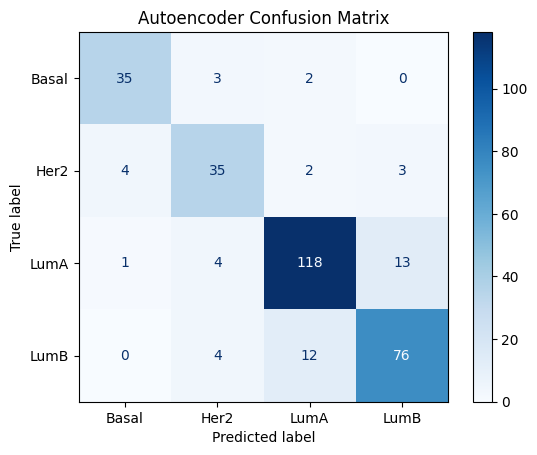

In [363]:
#valuate 
ae_classifier.eval()
ae_preds = []

with torch.no_grad():
    for x, y in test_loader:
        outputs = ae_classifier(x)
        preds = torch.argmax(outputs, dim=1)
        ae_preds.extend(preds.numpy())

print("AE Classifier Accuracy:", accuracy_score(y_test_encoded,ae_preds))
print(classification_report(y_test_encoded, ae_preds, target_names=label_encoder.classes_))

#confusion matrix
cm_ae = confusion_matrix(y_test_encoded, ae_preds)
ConfusionMatrixDisplay(cm_ae, display_labels=label_encoder.classes_).plot(cmap="Blues")
plt.title("Autoencoder Confusion Matrix")
plt.show()

In [322]:
print("MLP Accuracy:", accuracy_score(all_labels, all_preds))
print("AE Accuracy:", accuracy_score(y_test_encoded, ae_preds))

MLP Accuracy: 0.8461538461538461
AE Accuracy: 0.8461538461538461


In [ ]:
#VALIDATION

In [326]:
from sklearn.model_selection import cross_val_score
rf = RandomForestClassifier(random_state=42)
cv_scores = cross_val_score(rf, X_train, y_train, cv=5, scoring="accuracy")

print("Cross-validation accuracy scores:", cv_scores)
print("Mean CV accuracy:", cv_scores.mean())

Cross-validation accuracy scores: [0.796      0.84       0.84337349 0.79518072 0.81124498]
Mean CV accuracy: 0.8171598393574298


In [ ]:
#HYPERPARAMETER

In [339]:
from sklearn.model_selection import RandomizedSearchCV
rf = RandomForestClassifier(random_state=42)

param_dist = {
    "n_estimators": [100,200],
    "max_depth": [None, 10]
}
rf_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=5,
    cv=5,
    random_state=42,
    n_jobs=-1
)

rf_search.fit(X_train, y_train)
print("Best Parameters:", rf_search.best_params_)

/opt/anaconda3/envs/py311_env/lib/python3.11/site-packages/sklearn/model_selection/_search.py:324: UserWarning: The total space of parameters 4 is smaller than n_iter=5. Running 4 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Best Parameters: {'n_estimators': 200, 'max_depth': None}


In [343]:
#evaluate
best_rf = rf_search.best_estimator_
y_pred_rf_tuned = best_rf.predict(X_test)
print("Tuned RF Accuracy:", accuracy_score(y_test, y_pred_rf_tuned))
print(classification_report(y_test, y_pred_rf_tuned))

Tuned RF Accuracy: 0.8557692307692307
              precision    recall  f1-score   support

       Basal       1.00      0.85      0.92        40
        Her2       0.86      0.73      0.79        44
        LumA       0.86      0.91      0.88       136
        LumB       0.80      0.84      0.82        92

    accuracy                           0.86       312
   macro avg       0.88      0.83      0.85       312
weighted avg       0.86      0.86      0.86       312



In [ ]:
#VISUALS OF ALL MODELS 

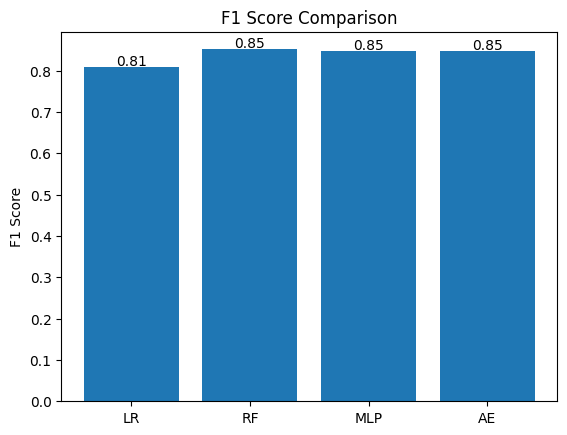

In [365]:
#f1 scores
from sklearn.metrics import f1_score
models = ["LR","RF","MLP","AE"]
f1_scores = [
    f1_score(y_test, y_pred_log, average="weighted"),
    f1_score(y_test, y_pred_rf, average="weighted"),
    f1_score(y_test_encoded, all_preds, average="weighted"),
    f1_score(y_test_encoded, ae_preds, average="weighted")
]

plt.bar(models, f1_scores)
plt.title("F1 Score Comparison")
plt.ylabel("F1 Score")
for i, v in enumerate(f1_scores):
    plt.text(i, v + 0.005, f"{v:.2f}", ha="center")
plt.show()

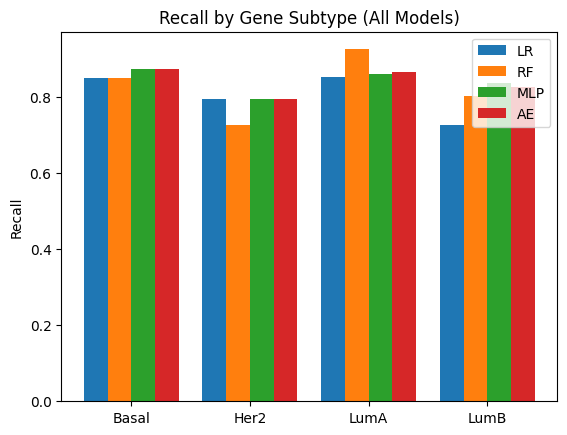

In [373]:
from sklearn.metrics import classification_report
import pandas as pd
import numpy as np

# get recall for each model
def get_recall(y_true, y_pred):
    report = classification_report(
        y_true,
        y_pred,
        target_names=label_encoder.classes_,
        output_dict=True
    )
    return [report[label]["recall"] for label in label_encoder.classes_]

recall_lr = get_recall(y_test, y_pred_log)
recall_rf = get_recall(y_test, y_pred_rf)
recall_mlp = get_recall(y_test_encoded, all_preds)
recall_ae = get_recall(y_test_encoded, ae_preds)

# labels
subtypes = label_encoder.classes_
x = np.arange(len(subtypes))

# plot
width = 0.2

plt.bar(x - 1.5*width, recall_lr, width, label="LR")
plt.bar(x - 0.5*width, recall_rf, width, label="RF")
plt.bar(x + 0.5*width, recall_mlp, width, label="MLP")
plt.bar(x + 1.5*width, recall_ae, width, label="AE")

plt.xticks(x, subtypes)
plt.ylabel("Recall")
plt.title("Recall by Gene Subtype (All Models)")
plt.legend()

plt.show()